In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, classification_report

In [137]:
from sklearn.preprocessing import OneHotEncoder
df = pd.read_csv("../datasets/CleanedDataSet_jh.csv")

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)



encoded_values = encoder.fit_transform(df[['hospital_ward', 'department_referral', 'doctor_specialty', 'patient_disease', 'discharge_status', 'patient_race']])

new_cols = encoder.get_feature_names_out(['hospital_ward', 'department_referral', 'doctor_specialty', 'patient_disease', 'discharge_status', 'patient_race'])

df["time_slot"] = pd.to_datetime(df["time_slot"], format="%I:%M:%S %p")

df["admission_hour"] = df["time_slot"].dt.hour  # 0-23
df["admission_minute"] = df["time_slot"].dt.minute

df["occupancy_ratio"] = df["occupied_beds"] / df["hospital_beds_available"]

age_bins = [0, 17, 39, 64, 200]
age_labels = [0, 1, 2, 3]  # pediatric, young adult, middle-aged, elderly
df["age_bucket"] = pd.cut(df["patient_age"], bins=age_bins, labels=age_labels, include_lowest=True).astype(int)

# Gender
df["patient_gender"] = df["patient_gender"].map({"Male": 1, "Female": 0}).fillna(-1)

df_encoded = pd.DataFrame(encoded_values, columns=new_cols, index=df.index)
data_final = pd.concat([df.drop(columns=['hospital_ward', 'department_referral', 'doctor_specialty', 'patient_disease', 'discharge_status', 'patient_race', 'time_slot', 'Admission_date', 'doctor_name', 'patient_last_name', 'patient_checkin_date', 'patient_checkout_date', 'hospital_id', 'patient_id']), df_encoded], axis=1)


data_final



,hospital_beds_available,occupied_beds,patient_gender,patient_age,patient_sat_score,patient_waittime,patient_assigned_doctor,patient_length_of_stay,readmission,admission_hour,...,patient_disease_Stroke,patient_disease_Urinary Tract Infection (UTI),discharge_status_Deceased,discharge_status_Recovered,discharge_status_Transferred,patient_race_Asian,patient_race_Black,patient_race_Hispanic,patient_race_Other,patient_race_White
0,260,90,0,48,490,120,False,6,1,14,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,250,90,1,40,1210,60,False,2,1,16,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,350,220,0,74,920,120,False,17,0,19,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,190,350,1,82,1010,75,False,28,0,7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,220,390,1,62,570,90,False,16,1,13,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,300,390,1,77,180,60,True,20,0,18,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9996,100,380,1,75,1360,75,True,29,1,8,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
9997,330,230,1,57,210,90,False,11,0,19,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9998,230,400,0,63,910,120,False,24,0,9,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [21]:
from sklearn.preprocessing import StandardScaler

In [168]:
X = data_final.drop(columns=["readmission"]).values

# y = just the label column
y = data_final["readmission"].values

from ucimlrepo import fetch_ucirepo

diabetes_130_us_hospitals = fetch_ucirepo(id=296)
X = diabetes_130_us_hospitals.data.features
y = diabetes_130_us_hospitals.data.targets

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_values = encoder.fit_transform(df[['hospital_ward', 'department_referral', 'doctor_specialty', 'patient_disease', 'discharge_status', 'patient_race']])

new_cols = encoder.get_feature_names_out(['hospital_ward', 'department_referral', 'doctor_specialty', 'patient_disease', 'discharge_status', 'patient_race'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'AfricanAmerican'

In [150]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [151]:
clf.score(X_test_scaled, y_test)

0.57

In [153]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

y_pred = clf.predict(X_test_scaled)

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=["No Readmission", "Readmission"]))

print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Classification Report
                precision    recall  f1-score   support

No Readmission       0.58      0.93      0.72      1175
   Readmission       0.37      0.06      0.11       825

      accuracy                           0.57      2000
     macro avg       0.48      0.49      0.41      2000
  weighted avg       0.50      0.57      0.46      2000

Confusion Matrix
[[1089   86]
 [ 774   51]]


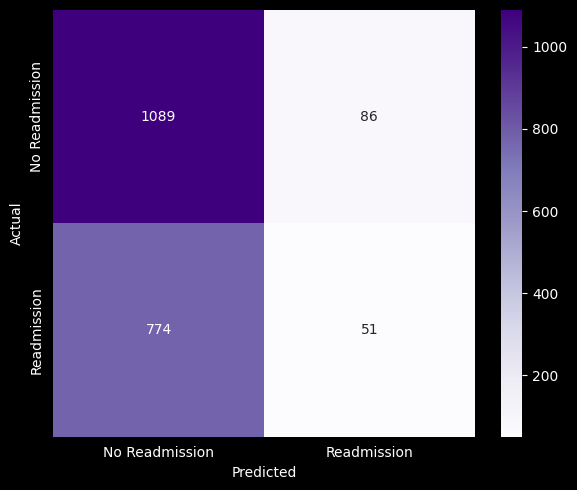

In [163]:
import matplotlib.pyplot as plt
import seaborn as sn

fig, ax = plt.subplots(figsize=(6, 5))

sn.heatmap(cm, annot=True, fmt="d", cmap="Purples",  xticklabels=["No Readmission", "Readmission"], yticklabels=["No Readmission", "Readmission"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")



In [136]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring="roc_auc")
print(f"5-Fold CV AUC-ROC scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

5-Fold CV AUC-ROC scores: [0.52821897 0.53839876 0.5071141  0.4982849  0.52785221]
Mean: 0.520 (+/- 0.015)


## Feature Engineering + Rebuilt Train/Test Split

## Model Comparison (with Class Balancing)

In [131]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
fitted_models = {}

for name, model in models.items():
    if name == "Gradient Boosting":
        # GradientBoosting doesn't support class_weight, use sample_weight
        sw = compute_sample_weight("balanced", y2_train)
        model.fit(X2_train_scaled, y2_train, sample_weight=sw)
    else:
        model.fit(X2_train_scaled, y2_train)

    y_pred = model.predict(X2_test_scaled)
    y_prob = model.predict_proba(X2_test_scaled)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y2_test, y_pred),
        "F1": f1_score(y2_test, y_pred),
        "AUC-ROC": roc_auc_score(y2_test, y_prob),
    }
    fitted_models[name] = model

results_df = pd.DataFrame(results).T
print(results_df.to_string(float_format="%.3f"))

                     Accuracy    F1  AUC-ROC
Logistic Regression     0.499 0.454    0.503
Random Forest           0.570 0.065    0.490
Gradient Boosting       0.495 0.438    0.493


## Hyperparameter Tuning (Best Model)

In [164]:
# Pick best model from comparison
best_name = results_df["AUC-ROC"].idxmax()
print(f"Best model: {best_name} (AUC-ROC: {results_df.loc[best_name, 'AUC-ROC']:.3f})")

# Hyperparameter grid for Random Forest (most likely best or close)
param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", random_state=42),
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV AUC-ROC: {grid_search.best_score_:.3f}")

Best model: Logistic Regression (AUC-ROC: 0.503)


ValueError: Invalid parameter 'max_depth' for estimator LogisticRegression(class_weight='balanced', random_state=42). Valid parameters are: ['C', 'class_weight', 'dual', 'fit_intercept', 'intercept_scaling', 'l1_ratio', 'max_iter', 'n_jobs', 'penalty', 'random_state', 'solver', 'tol', 'verbose', 'warm_start'].

## Final Evaluation (Tuned Model)

=== Classification Report (Tuned Model) ===
                precision    recall  f1-score   support

No Readmission       0.57      0.89      0.70      1152
   Readmission       0.40      0.10      0.15       848

      accuracy                           0.56      2000
     macro avg       0.49      0.49      0.43      2000
  weighted avg       0.50      0.56      0.47      2000

=== Confusion Matrix ===
[[1030  122]
 [ 767   81]]

AUC-ROC: 0.497


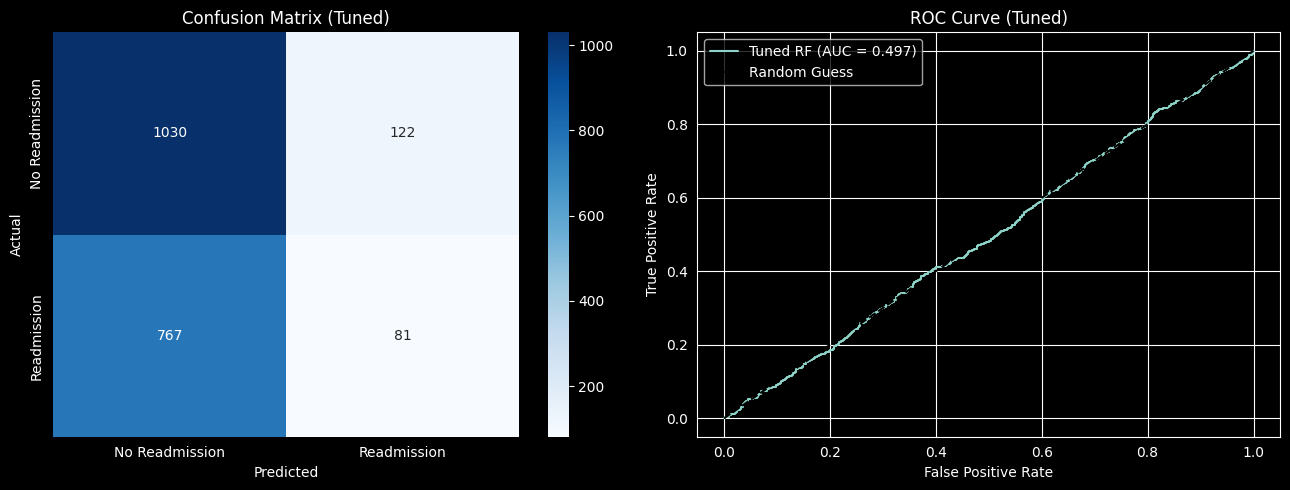

In [134]:
best_clf = grid_search.best_estimator_

y_final_pred = best_clf.predict(X2_test_scaled)
y_final_prob = best_clf.predict_proba(X2_test_scaled)[:, 1]

print("=== Classification Report (Tuned Model) ===")
print(classification_report(y2_test, y_final_pred, target_names=["No Readmission", "Readmission"]))

print("=== Confusion Matrix ===")
cm_final = confusion_matrix(y2_test, y_final_pred)
print(cm_final)

final_auc = roc_auc_score(y2_test, y_final_prob)
print(f"\nAUC-ROC: {final_auc:.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix heatmap
sb.heatmap(cm_final, annot=True, fmt="d", cmap="Blues",
           xticklabels=["No Readmission", "Readmission"],
           yticklabels=["No Readmission", "Readmission"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix (Tuned)")

# ROC curve
fpr_f, tpr_f, _ = roc_curve(y2_test, y_final_prob)
axes[1].plot(fpr_f, tpr_f, label=f"Tuned RF (AUC = {final_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random Guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Tuned)")
axes[1].legend()

plt.tight_layout()
plt.show()